# SUPPORT VECTOR MACHINE

In [105]:
# Importing required Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)
%matplotlib inline

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV

### Task 1: Exploratory Data Analysis (EDA)

In [5]:
# Loading Dataset
df=pd.read_csv('C:/Data Science/Assignments_Files/SVM/mushroom.csv')
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,stalk_root,stalk_surface_above_ring,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,tapering,cup,smooth,silky,gray,yellow,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,enlarging,rooted,silky,silky,cinnamon,brown,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,tapering,cup,scaly,silky,yellow,gray,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,enlarging,club,smooth,scaly,yellow,pink,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,enlarging,missing,fibrous,scaly,gray,white,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [7]:
# Checking dataset size
df.shape

(2000, 26)

In [9]:
# Checking Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [11]:
# Understanding Statistical Information
df.describe()

,Unnamed: 0,stalk_height,cap_diameter
count,2000.000000,2000.000000,2000.000000
mean,624.974000,8.449118,12.314345
std,375.091938,3.697217,7.048845
min,0.000000,2.000000,1.000000
25%,290.000000,5.291009,5.723521
50%,607.000000,8.318596,12.124902
75%,957.250000,11.781272,18.698605
max,1279.000000,15.095066,25.000054


In [13]:
# Removing Unnecessary Columns
df.drop(columns={'Unnamed: 0'},axis=1,inplace=True)

In [17]:
# Checking for duplicates
df.duplicated().sum()

np.int64(1024)

In [21]:
# Removing Duplicates
df.drop_duplicates(inplace=True)

In [23]:
# Verifying duplicates removed or not
df.duplicated().sum()

np.int64(0)

In [25]:
# Check for Missing values
df.isna().sum()

cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

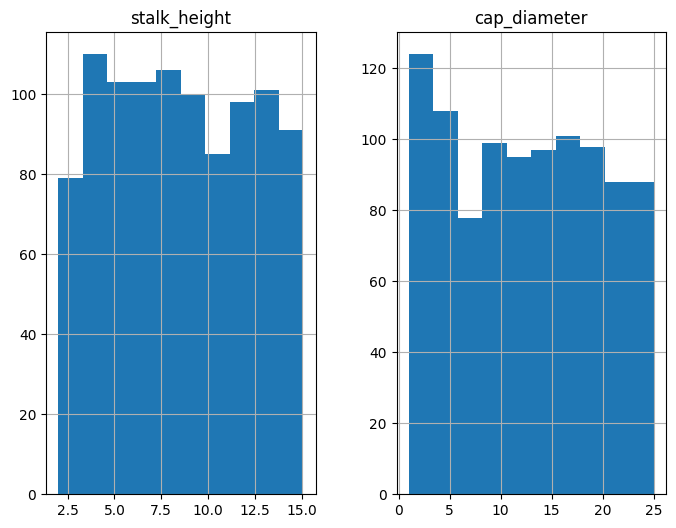

In [29]:
# Data Visualization
# Histograms
df.hist(figsize=(8,6))
plt.show()

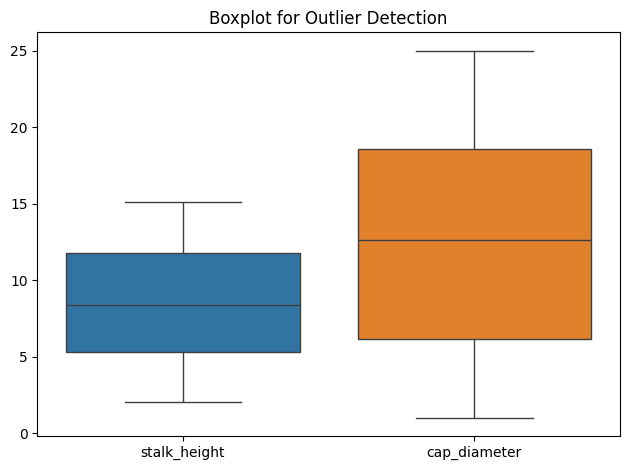

In [31]:
# Boxplot for Outlier Detection
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

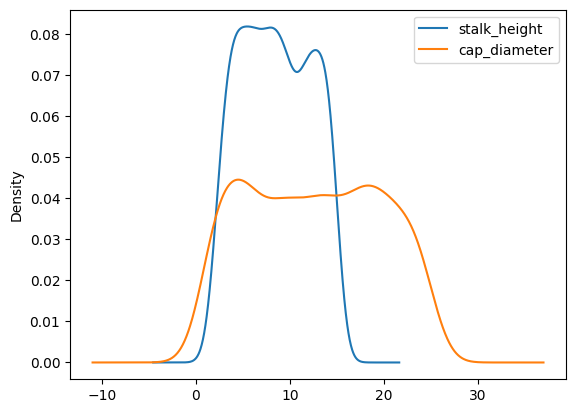

In [33]:
# Density Plot
df.plot(kind="density")
plt.show()

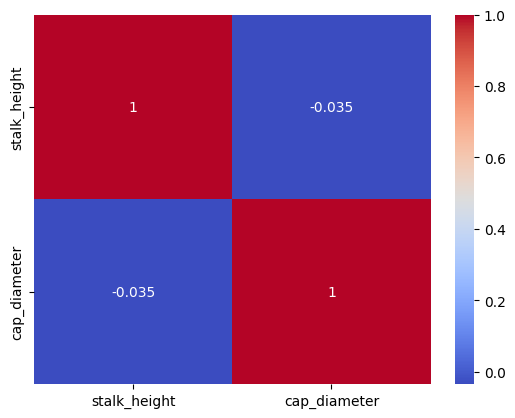

In [35]:
# Feature Correlation
# 1. Numerical Correlation
corr = df[['stalk_height', 'cap_diameter']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

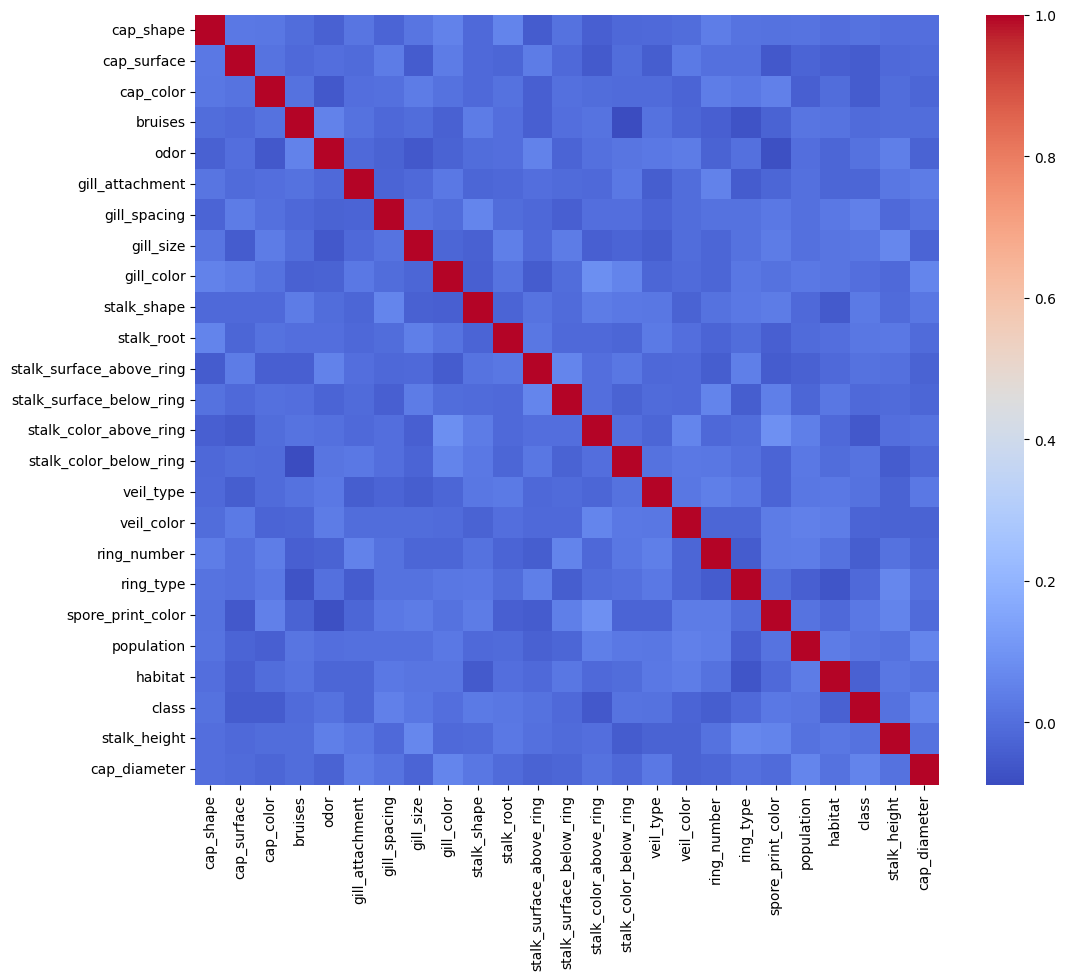

In [39]:
# 2. Categorical Correlation
le = LabelEncoder()
df_encoded = df.apply(lambda col: le.fit_transform(col.astype(str)))

corr = df_encoded.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

### Task 2: Data Preprocessing

In [42]:
# View encoded data
df_encoded.head()

,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,stalk_shape,stalk_root,stalk_surface_above_ring,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,4,2,7,0,1,1,2,0,7,1,2,3,2,3,8,0,0,2,6,3,1,5,1,302,776
1,4,0,6,0,1,3,1,1,3,0,6,2,2,2,0,1,0,2,6,1,2,5,0,487,405
2,3,1,5,1,4,1,1,0,8,1,2,1,2,8,3,1,3,2,6,6,0,5,1,896,867
3,0,2,4,1,3,3,0,0,6,0,1,3,1,8,5,0,3,2,0,4,1,0,1,593,538
4,3,3,8,1,5,2,1,1,6,0,4,0,1,3,7,1,2,0,4,8,1,4,1,281,139


In [44]:
# Split Dataset into Features & Target
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

In [50]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [54]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Task 3: Data Visualization

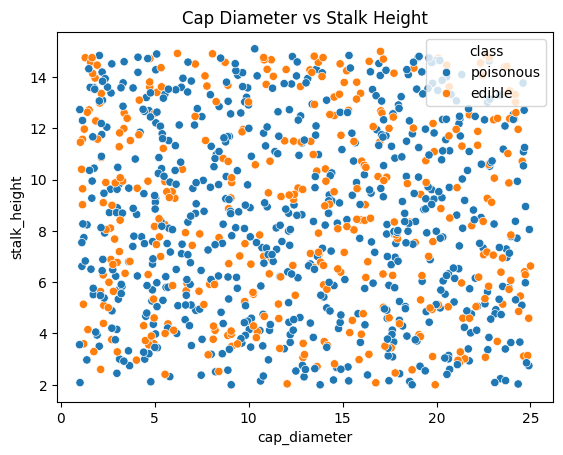

In [57]:
# Scatter Plot 
sns.scatterplot(
    x='cap_diameter',
    y='stalk_height',
    hue='class',
    data=df
)
plt.title("Cap Diameter vs Stalk Height")
plt.show()

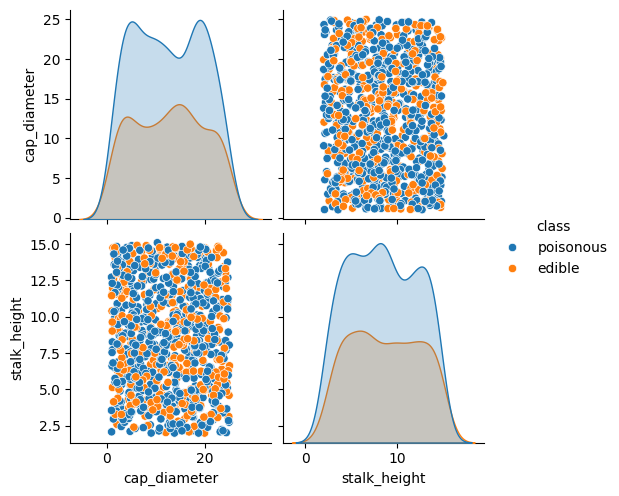

In [59]:
# Pairplot
sns.pairplot(df[['cap_diameter', 'stalk_height', 'class']], hue='class')
plt.show()

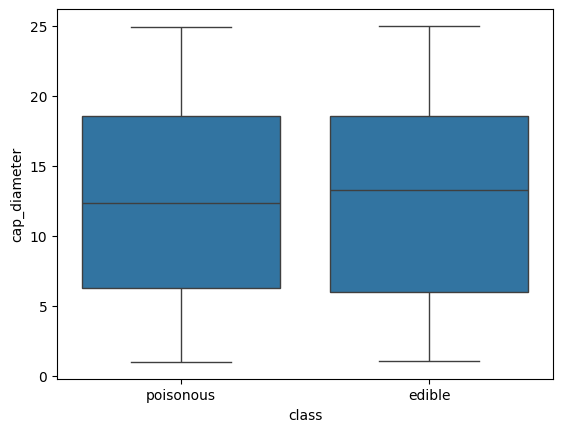

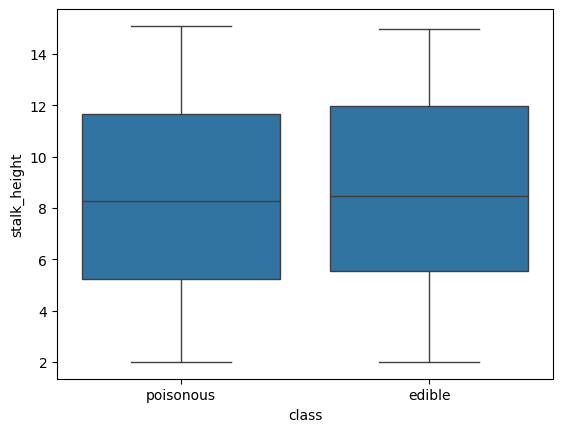

In [61]:
# Box Plot (Outlier Detection)
sns.boxplot(x='class', y='cap_diameter', data=df)
plt.show()

sns.boxplot(x='class', y='stalk_height', data=df)
plt.show()

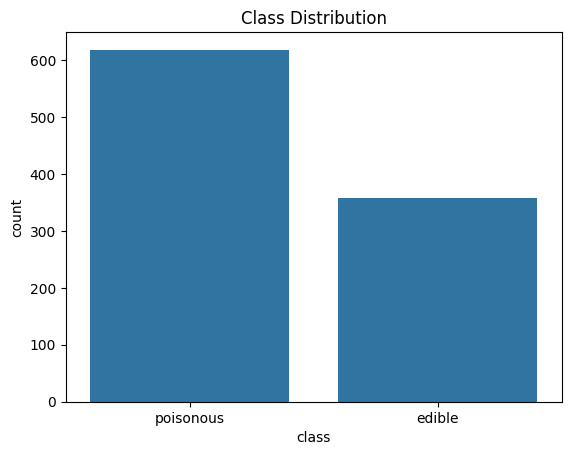

In [63]:
# Visualizing Class Distribution
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

In [67]:
# Percentage Distribution
df['class'].value_counts(normalize=True) * 100

class
poisonous    63.319672
edible       36.680328
Name: proportion, dtype: float64

### Task 4: SVM Implementation

In [72]:
# Train the SVM Model
# Initialize SVM model
svm_model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')
# Train model
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [74]:
# Making Predictions
y_pred = svm_model.predict(X_test)

In [76]:
# Evaluating Model Performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.5


In [78]:
# Printing Classifiction Rreport
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.35      0.40      0.37        72
           1       0.62      0.56      0.58       124

    accuracy                           0.50       196
   macro avg       0.48      0.48      0.48       196
weighted avg       0.52      0.50      0.51       196



In [80]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[29 43]
 [55 69]]


### Task 5: Visualization of SVM Results

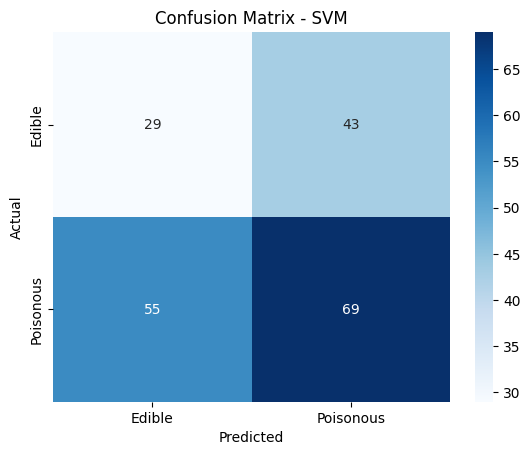

In [83]:
# Confusion Matrix Visualization
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible', 'Poisonous'],
            yticklabels=['Edible', 'Poisonous'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

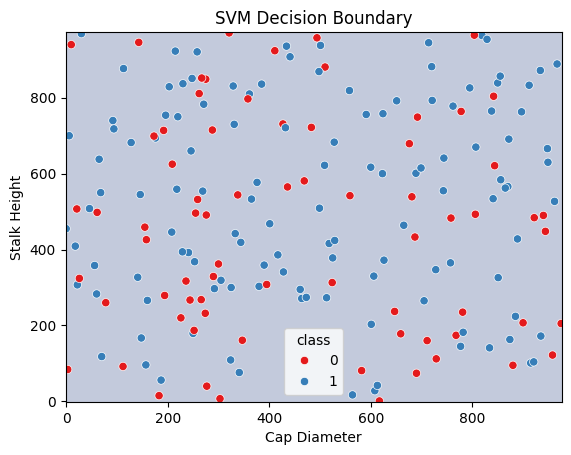

In [87]:
# Decision Boundary Visualization
# Use only 2 features
X_vis = df_encoded[['cap_diameter', 'stalk_height']]
y_vis = df_encoded['class']

# Train-test split
from sklearn.model_selection import train_test_split
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.2, random_state=42
)

# Train SVM
model_vis = SVC(kernel='rbf')
model_vis.fit(X_train_vis, y_train_vis)

# Create meshgrid
x_min, x_max = X_vis.iloc[:, 0].min() - 1, X_vis.iloc[:, 0].max() + 1
y_min, y_max = X_vis.iloc[:, 1].min() - 1, X_vis.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Predict for grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_test_vis.iloc[:,0],
                y=X_test_vis.iloc[:,1],
                hue=y_test_vis,
                palette='Set1')

plt.xlabel("Cap Diameter")
plt.ylabel("Stalk Height")
plt.title("SVM Decision Boundary")
plt.show()

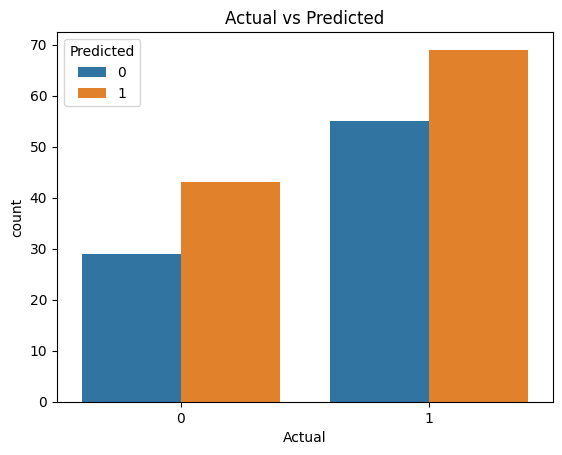

In [89]:
# Actual vs Predicted Visualization
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

sns.countplot(x='Actual', hue='Predicted', data=results)
plt.title("Actual vs Predicted")
plt.show()

### Task 6: Parameter Tuning and Optimization

In [94]:
# Using GridSearchCV for Optimization
# Define parameter grid
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# Initialize model
svm = SVC(class_weight='balanced')

# Grid search
grid = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

# Fit model
grid.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_weight='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is

In [96]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [98]:
# Best Model Evaluation
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.5408163265306123
              precision    recall  f1-score   support

           0       0.36      0.32      0.34        72
           1       0.63      0.67      0.65       124

    accuracy                           0.54       196
   macro avg       0.49      0.49      0.49       196
weighted avg       0.53      0.54      0.53       196



### Task 7: Comparison and Analysis

In [107]:
kernels = ['linear', 'poly', 'rbf']
results = {}

for k in kernels:
    model = SVC(kernel=k, class_weight='balanced')
    model.fit(X_train, y_train)
    y_pred_k = model.predict(X_test)
    
    results[k] = {
        "Accuracy": accuracy_score(y_test, y_pred_k),
        "F1 Score": f1_score(y_test, y_pred_k)
    }

results

{'linear': {'Accuracy': 0.5, 'F1 Score': 0.5420560747663551},
 'poly': {'Accuracy': 0.5357142857142857, 'F1 Score': 0.6403162055335968},
 'rbf': {'Accuracy': 0.5, 'F1 Score': 0.5847457627118644}}

##  SVM Analysis (Strengths & Weaknesses)

From the results:

- Linear → Accuracy: 0.50, F1: 0.54  
- Polynomial → Accuracy: 0.54, F1: 0.64  
- RBF → Accuracy: 0.50, F1: 0.58  

### Observations
- Overall accuracy is quite low (~50–54%), so the model is not performing well  
- Polynomial kernel gives slightly better results than others  
- RBF did not perform as expected despite handling non-linear data  

### Strengths
- SVM can handle high-dimensional data  
- Works with non-linear relationships (seen with polynomial kernel)  
- F1-score is better than accuracy, so it handles class imbalance reasonably  

### Weaknesses
- Poor accuracy indicates weak learning from data  
- Sensitive to encoding (categorical data may not be handled properly)  
- Numerical features show weak separation (from EDA)  
- Requires proper tuning (C, gamma) for better performance  

### Conclusion
SVM did not perform well on this dataset mainly due to categorical-heavy features and weak separability. Better encoding and tuning could improve results.